<div style="background: linear-gradient(135deg, #0d3b66 0%, #1a5c8a 60%, #2e86c1 100%); padding: 40px; border-radius: 16px; color: white; text-align: center; margin-bottom: 20px;">
  <h1 style="font-size: 2em; margin-bottom: 8px;">🌱 SmartRoot</h1>
  <h2 style="font-weight: 300; font-size: 1.15em; margin-bottom: 18px;">Sistema portátil para estimación del potencial mátrico del suelo<br>mediante resistividad eléctrica y aprendizaje automático</h2>
  <hr style="border-color: rgba(255,255,255,0.3); margin: 16px 0;">
  <h3 style="font-weight: 400;">📓 Notebook 03 — Programación Orientada a Objetos (POO)</h3>
  <p style="opacity: 0.85;">Clases · Herencia · Polimorfismo · Objetos · Métodos · Atributos</p>
  <p style="opacity: 0.7; font-size: 0.9em;">Fundamentos de Programación Científica · Maestría en Automatización y Control Industrial</p>
</div>

---

## ¿Qué construimos en este notebook?

En los notebooks anteriores programamos de forma **procedural** (función por función). Ahora damos el salto a la **Programación Orientada a Objetos (POO)**: organizamos el sistema SmartRoot como una colección de *objetos* que tienen propiedades y saben hacer cosas.

### La analogía del mundo real

Imagina que diseñas el sistema SmartRoot físicamente:
- Tienes varios tipos de **sensores** (tensiómetros, Gypsum resistivos, capacitivos).
- Cada sensor tiene **propiedades**: ubicación, tipo, precisión, costo.
- Cada sensor sabe hacer cosas: **leer** el suelo, **clasificar** el estado hídrico, **reportar** su estado.
- Todos los sensores comparten cosas en común (todos miden algo del suelo), pero cada tipo tiene su propia forma de medirlo.
- Una **parcela** contiene varios sensores y puede resumir el estado global.

Esto es exactamente lo que representa la POO en código.

---

### 📌 Contexto: lo que tenemos hasta aquí

| Notebook | Resultado clave |
|---|---|
| NB01 EDA | Dataset limpio: 2.494 registros, 8 variables, Mayo–Julio 2016 |
| NB02 Básica | 3 KPIs: ψ_prom=195.6 hPa 🟢, MAPE=13.3% 🟢, T_óptima=74.5% 🟢 |
| **NB03 POO** | **Modelamos sensores, mediciones y parcela como objetos Python** |

---
## Sección 0 — Configuración del entorno

In [1]:
# ============================================================
# SMARTROOT — Celda de inicio (ejecutar siempre primero)
# ============================================================
from google.colab import drive
import sys, os
drive.mount('/content/drive')

BASE      = '/content/drive/MyDrive/POSGRADO/2026-1/FUNDAMENTOS DE PROGRAMACIÓN CIENTÍFICA/CLASES/PROYECTO_FINAL'
DATA_PROC = f'{BASE}/data/processed'
FIGS      = f'{BASE}/outputs/figuras'
TABS      = f'{BASE}/outputs/tablas'
SRC       = f'{BASE}/src'
sys.path.insert(0, SRC)

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from abc import ABC, abstractmethod   # para clases abstractas
import warnings
warnings.filterwarnings('ignore')

VERDE = '#40916c'; AMARILLO = '#f4a261'; ROJO = '#e63946'
AZUL  = '#457b9d'; GRIS    = '#6c757d'; AZUL_OSC = '#0d3b66'

plt.rcParams.update({
    'figure.dpi': 120, 'figure.figsize': (14, 5),
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
})

# Cargar el dataset corregido generado en el NB02
df = pd.read_csv(f'{DATA_PROC}/dataset_corregido.csv', index_col=0, parse_dates=True)
print(f'✅ Entorno listo. Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'   Período: {df.index.min().date()} → {df.index.max().date()}')

Mounted at /content/drive
✅ Entorno listo. Dataset cargado: 2,494 filas × 8 columnas
   Período: 2016-05-13 → 2016-07-04


---
## Sección 1 — Conceptos fundamentales de POO

### Los cuatro pilares que aplicaremos

| Concepto | Definición | Cómo aparece en SmartRoot |
|---|---|---|
| **Clase** | Plantilla o molde para crear objetos | `Sensor`, `SensorResistivo`, `Parcela` |
| **Objeto** | Instancia concreta de una clase | `gypsum_1`, `parcela_jki` |
| **Atributo** | Dato que pertenece a un objeto | `sensor.ubicacion_x`, `sensor.costo_usd` |
| **Método** | Función que pertenece a un objeto | `sensor.leer()`, `parcela.estado_hidrico()` |
| **Herencia** | Una clase hija hereda de una clase madre | `SensorResistivo` hereda de `Sensor` |
| **Polimorfismo** | Mismo nombre de método, comportamiento diferente | `leer()` en cada tipo de sensor |
| **Encapsulamiento** | Datos protegidos dentro del objeto | Atributos con `_` para uso interno |

### ¿Por qué usar POO en SmartRoot?

Sin POO, el sistema SmartRoot sería un conjunto de funciones sueltas que no reflejan la realidad del hardware. **Con POO**, cada sensor es un objeto independiente con su propia historia de mediciones, sus propios parámetros de calibración y sus propias reglas de clasificación.

Cuando agreguemos un nuevo tipo de sensor (por ejemplo, un sensor de conductividad eléctrica), solo necesitamos crear una nueva clase hija — el resto del sistema no cambia.

---
## Sección 2 — Clase base: `Sensor`

La clase `Sensor` es la **clase madre** de toda la jerarquía. Define los atributos y métodos que **todos los sensores de suelo comparten**, independientemente de su tecnología. Es una clase abstracta — no se puede instanciar directamente, solo a través de sus clases hijas.

In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CLASE BASE: Sensor
# Clase abstracta — define la interfaz común para todos los sensores
# de suelo del sistema SmartRoot.
# ═══════════════════════════════════════════════════════════════════════════

class Sensor(ABC):
    """
    Clase base abstracta para todos los sensores de suelo del sistema SmartRoot.

    Representa un sensor físico instalado en campo que mide una o más
    variables del suelo. Todos los tipos de sensores heredan de esta clase
    y deben implementar los métodos abstractos: leer() y clasificar_estado().

    Atributos de clase (compartidos por todas las instancias):
        UMBRALES_PSI: dict con los umbrales agronómicos del potencial mátrico

    Atributos de instancia:
        id_sensor   : identificador único del sensor
        nombre      : nombre descriptivo
        ubicacion_x : posición X en la parcela [metros]
        ubicacion_y : posición Y en la parcela [metros]
        profundidad : profundidad de instalación [cm]
        costo_usd   : costo unitario del sensor [USD]
        activo      : si el sensor está operativo
        _historial  : lista privada de mediciones (encapsulamiento)
    """

    # Atributo de clase: compartido por TODOS los sensores
    UMBRALES_PSI = {
        'humedo'  : 100,   # hPa — por debajo: suelo muy húmedo
        'optimo'  : 300,   # hPa — entre 100 y 300: zona ideal
        'seco'    : 400,   # hPa — entre 300 y 400: programar riego
        'critico' : 400,   # hPa — por encima: riego urgente
    }

    def __init__(self, id_sensor, nombre, ubicacion_x, ubicacion_y,
                 profundidad_cm=20, costo_usd=0):
        """
        Constructor: se ejecuta automáticamente al crear un objeto Sensor.
        Inicializa todos los atributos de la instancia.
        """
        self.id_sensor    = id_sensor          # str: identificador único
        self.nombre       = nombre             # str: nombre descriptivo
        self.ubicacion_x  = ubicacion_x        # float: posición X [m]
        self.ubicacion_y  = ubicacion_y        # float: posición Y [m]
        self.profundidad  = profundidad_cm     # float: profundidad [cm]
        self.costo_usd    = costo_usd          # float: costo [USD]
        self.activo       = True               # bool: sensor operativo
        self._historial   = []                 # list: historial de lecturas (privado)
        self._n_lecturas  = 0                  # int: contador de lecturas

    # ── Métodos abstractos: DEBEN ser implementados por las clases hijas ──
    @abstractmethod
    def leer(self, valor_raw):
        """
        Procesa una lectura cruda del sensor y retorna el valor en hPa.
        Cada tipo de sensor tiene su propia lógica de conversión.
        → POLIMORFISMO: mismo nombre, diferente implementación.
        """
        pass

    @abstractmethod
    def tipo_sensor(self):
        """Retorna el tipo de sensor como string."""
        pass

    # ── Métodos concretos: heredados por todas las clases hijas ───────────
    def registrar_lectura(self, timestamp, valor_hpa, temperatura_c=None):
        """
        Guarda una lectura en el historial del sensor.
        Llamado automáticamente después de leer().

        Parámetros:
            timestamp    : datetime — momento de la medición
            valor_hpa    : float — potencial mátrico en hPa
            temperatura_c: float — temperatura del suelo (opcional)
        """
        if not self.activo:
            print(f'  ⚠️  Sensor {self.id_sensor} inactivo — lectura descartada.')
            return

        lectura = {
            'timestamp'   : timestamp,
            'psi_hpa'     : round(valor_hpa, 2),
            'temperatura' : temperatura_c,
            'estado'      : self.clasificar_estado(valor_hpa),
        }
        self._historial.append(lectura)
        self._n_lecturas += 1

    def clasificar_estado(self, psi_hpa):
        """
        Clasifica el estado hídrico según el potencial mátrico.
        Usa los UMBRALES_PSI de la clase.

        Retorna: str — 'humedo', 'optimo', 'seco' o 'critico'
        """
        if psi_hpa <= self.UMBRALES_PSI['humedo']:
            return 'humedo'
        elif psi_hpa <= self.UMBRALES_PSI['optimo']:
            return 'optimo'
        elif psi_hpa <= self.UMBRALES_PSI['critico']:
            return 'seco'
        else:
            return 'critico'

    def estadisticas(self):
        """
        Calcula estadísticas del historial de lecturas del sensor.
        Retorna dict con min, max, promedio, std y conteo por estado.
        """
        if not self._historial:
            return {'error': 'Sin lecturas registradas'}

        valores = [l['psi_hpa'] for l in self._historial]
        estados = [l['estado']  for l in self._historial]

        conteo_estados = {}
        for e in estados:
            conteo_estados[e] = conteo_estados.get(e, 0) + 1

        return {
            'n_lecturas'    : self._n_lecturas,
            'psi_min'       : round(min(valores),             2),
            'psi_max'       : round(max(valores),             2),
            'psi_promedio'  : round(sum(valores)/len(valores), 2),
            'psi_std'       : round(np.std(valores),          2),
            'conteo_estados': conteo_estados,
        }

    def semaforo(self):
        """
        Retorna el estado actual del sensor como semáforo.
        Usa el promedio de las últimas 4 lecturas (2 horas).
        """
        if len(self._historial) == 0:
            return {'color': GRIS, 'emoji': '⚪', 'estado': 'sin datos'}

        ultimas = self._historial[-4:]   # últimas 4 lecturas = 2 horas
        psi_reciente = sum(l['psi_hpa'] for l in ultimas) / len(ultimas)
        estado = self.clasificar_estado(psi_reciente)

        mapa = {
            'humedo'  : (AZUL,     '💧', 'Suelo húmedo — sin riego'),
            'optimo'  : (VERDE,    '🟢', 'Zona óptima — sin acción'),
            'seco'    : (AMARILLO, '🟡', 'Suelo seco — programar riego'),
            'critico' : (ROJO,     '🔴', 'Crítico — riego urgente'),
        }
        color, emoji, descripcion = mapa[estado]
        return {'color': color, 'emoji': emoji, 'estado': estado,
                'psi_reciente': round(psi_reciente, 1), 'descripcion': descripcion}

    def __str__(self):
        """Representación legible del sensor al imprimirlo."""
        return (f'[{self.tipo_sensor()}] {self.id_sensor} | '
                f'Pos: ({self.ubicacion_x}m, {self.ubicacion_y}m) | '
                f'Prof: {self.profundidad}cm | '
                f'Costo: USD {self.costo_usd} | '
                f'Lecturas: {self._n_lecturas}')

    def __repr__(self):
        """Representación técnica del objeto."""
        return f'Sensor(id={self.id_sensor!r}, tipo={self.tipo_sensor()!r})'


print('✅ Clase base Sensor definida.')
print('   Atributos: id_sensor, nombre, ubicacion_x/y, profundidad, costo_usd, activo')
print('   Métodos  : registrar_lectura(), clasificar_estado(), estadisticas(), semaforo()')
print('   Abstractos: leer(), tipo_sensor()  ← deben implementarse en cada clase hija')

✅ Clase base Sensor definida.
   Atributos: id_sensor, nombre, ubicacion_x/y, profundidad, costo_usd, activo
   Métodos  : registrar_lectura(), clasificar_estado(), estadisticas(), semaforo()
   Abstractos: leer(), tipo_sensor()  ← deben implementarse en cada clase hija


---
## Sección 3 — Clases hijas: herencia y polimorfismo

### ¿Qué es la herencia?

Una **clase hija** hereda todos los atributos y métodos de su clase madre, y puede:
1. **Agregar** nuevos atributos y métodos propios.
2. **Sobreescribir** métodos heredados con una versión especializada.

### ¿Qué es el polimorfismo?

El método `leer()` tiene el **mismo nombre** en todas las clases, pero **hace cosas diferentes** según el tipo de sensor. Esto permite tratar todos los sensores de la misma manera en el código, aunque internamente funcionen distinto.

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# CLASE HIJA 1: SensorResistivo
# Hereda de Sensor. Representa el sensor Gypsum (bloque de yeso).
# Este es el sensor central de la tesis SmartRoot:
# mide resistencia eléctrica y la convierte a potencial mátrico.
# ═══════════════════════════════════════════════════════════════════════════

class SensorResistivo(Sensor):   # ← hereda de Sensor
    """
    Sensor de potencial mátrico basado en resistencia eléctrica.

    Principio físico:
        El bloque de yeso (Gypsum) se equilibra con la humedad del suelo.
        A mayor humedad → menor resistencia eléctrica → menor ψ.
        La relación R↔ψ se corrige con la temperatura del suelo.

    Curva de calibración Watermark (estándar industrial):
        ψ = R × factor_temp  →  en hPa
        factor_temp = 1 - 0.0025 × (T - 24)  [corrección lineal Watermark]

    Atributos adicionales (propios de este tipo):
        material       : material del bloque sensor
        rango_min_hpa  : mínimo detectable [hPa]
        rango_max_hpa  : máximo detectable [hPa]
        factor_cal     : factor de calibración individual
    """

    def __init__(self, id_sensor, nombre, ubicacion_x, ubicacion_y,
                 profundidad_cm=20, costo_usd=25, factor_cal=1.0):
        # Llamar al constructor de la clase madre (Sensor)
        super().__init__(id_sensor, nombre, ubicacion_x, ubicacion_y,
                         profundidad_cm, costo_usd)
        # Atributos específicos del sensor resistivo
        self.material      = 'Yeso (CaSO₄·2H₂O)'   # material del bloque
        self.rango_min_hpa = 50.0                    # mínimo según datasheet
        self.rango_max_hpa = 350.0                   # máximo según datasheet
        self.factor_cal    = factor_cal              # factor de calibración individual
        self._ultima_temp  = 20.0                    # temperatura de referencia [°C]

    def tipo_sensor(self):   # ← implementa método abstracto
        return 'EPM-Resistencia (Gypsum)'

    def leer(self, valor_raw, temperatura_c=20.0):   # ← POLIMORFISMO
        """
        Convierte la lectura cruda del Gypsum (en hPa pre-calibrado)
        aplicando la corrección por temperatura del suelo.

        Curva Watermark (IRROMETER, 2006):
            factor_temp = 1 - 0.0025 × (T - 24)
            ψ_corregido = valor_raw × factor_temp × factor_cal

        Parámetros:
            valor_raw    : float — lectura del sensor [hPa, sin corrección]
            temperatura_c: float — temperatura del suelo [°C]
        Retorna:
            float — potencial mátrico corregido [hPa]
        """
        self._ultima_temp = temperatura_c

        # Corrección por temperatura (modelo lineal Watermark)
        factor_temp = 1.0 - 0.0025 * (temperatura_c - 24.0)
        psi_corregido = valor_raw * factor_temp * self.factor_cal

        # Aplicar límites físicos del sensor
        psi_corregido = max(self.rango_min_hpa,
                            min(psi_corregido, self.rango_max_hpa))
        return round(psi_corregido, 2)

    def costo_por_punto(self, n_puntos):
        """Método propio: calcula el costo total para cubrir n_puntos de medición."""
        return self.costo_usd * n_puntos

    def ahorro_vs_tensiometro(self, costo_tensiometro=400):
        """Método propio: calcula el ahorro porcentual vs un tensiómetro comercial."""
        ahorro = (1 - self.costo_usd / costo_tensiometro) * 100
        return round(ahorro, 1)


print('✅ SensorResistivo definido (hereda de Sensor).')
print('   Atributos propios: material, rango_min/max_hpa, factor_cal')
print('   Métodos propios  : costo_por_punto(), ahorro_vs_tensiometro()')
print('   leer()           : aplica corrección Watermark por temperatura ← POLIMORFISMO')

✅ SensorResistivo definido (hereda de Sensor).
   Atributos propios: material, rango_min/max_hpa, factor_cal
   Métodos propios  : costo_por_punto(), ahorro_vs_tensiometro()
   leer()           : aplica corrección Watermark por temperatura ← POLIMORFISMO


In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# CLASE HIJA 2: SensorTensiometro
# Hereda de Sensor. Representa los tensiómetros de referencia (T4, T5).
# Son el gold standard: miden presión hidráulica directamente.
# ═══════════════════════════════════════════════════════════════════════════

class SensorTensiometro(Sensor):   # ← hereda de Sensor
    """
    Tensiómetro de cerámica — sensor de referencia del sistema.

    Principio físico:
        Una cápsula cerámica porosa se equilibra con el agua del suelo.
        La presión negativa (succión) se mide directamente con un manómetro.
        Sin conversión necesaria: la lectura ya es el potencial mátrico real.

    Atributos adicionales:
        cuerpo        : material del cuerpo del tensiómetro
        rango_max_hpa : rango máximo confiable [hPa]
        requiere_agua : si necesita llenado periódico de agua
    """

    def __init__(self, id_sensor, nombre, ubicacion_x, ubicacion_y,
                 profundidad_cm=20, costo_usd=400):
        super().__init__(id_sensor, nombre, ubicacion_x, ubicacion_y,
                         profundidad_cm, costo_usd)
        self.cuerpo        = 'Cerámica porosa + cuerpo PVC'
        self.rango_max_hpa = 850.0   # límite del manómetro estándar
        self.requiere_agua = True    # necesita mantenimiento periódico

    def tipo_sensor(self):   # ← implementa método abstracto
        return 'Tensiómetro (referencia)'

    def leer(self, valor_raw, temperatura_c=None):   # ← POLIMORFISMO
        """
        El tensiómetro mide ψ directamente — no requiere conversión.
        Solo valida que el valor esté dentro del rango operativo.
        temperatura_c no se usa (el tensiómetro no es sensible a la T).
        """
        if valor_raw > self.rango_max_hpa:
            # Tensiómetro fuera de rango: cavitación del agua interna
            print(f'  ⚠️  {self.id_sensor}: valor {valor_raw:.0f} hPa supera el rango. '
                  f'Tensiómetro requiere mantenimiento.')
            return self.rango_max_hpa  # devolver límite como señal de alerta
        return round(valor_raw, 2)

    def alertar_mantenimiento(self, dias_sin_relleno):
        """Método propio: alerta si el tensiómetro necesita relleno de agua."""
        if dias_sin_relleno > 30:
            return f'⚠️  {self.id_sensor}: relleno urgente ({dias_sin_relleno} días sin mantenimiento)'
        elif dias_sin_relleno > 14:
            return f'🟡 {self.id_sensor}: próximo relleno recomendado'
        return f'🟢 {self.id_sensor}: sin mantenimiento requerido'


# ═══════════════════════════════════════════════════════════════════════════
# CLASE HIJA 3: SensorCapacitivo
# Hereda de Sensor. Representa los sensores 10HS y ECTM (humedad volumétrica).
# Miden permitividad dieléctrica y la convierten a humedad volumétrica.
# ═══════════════════════════════════════════════════════════════════════════

class SensorCapacitivo(Sensor):   # ← hereda de Sensor
    """
    Sensor capacitivo de humedad volumétrica (10HS, ECTM).

    Principio físico:
        Mide la permitividad dieléctrica del suelo, que depende
        del contenido de agua. La convierte a humedad volumétrica θ [m³/m³].
        Para obtener ψ, aplica la ecuación de Van Genuchten con los
        parámetros físicos del suelo del sitio.

    Atributos adicionales:
        vg_alpha, vg_n, vg_theta_r, vg_theta_s : parámetros Van Genuchten
    """

    # Parámetros Van Genuchten del sitio JKI (Jackisch et al., 2018)
    VG_ALPHA   = 0.0264
    VG_N       = 3.044
    VG_THETA_R = 0.007
    VG_THETA_S = 0.361

    def __init__(self, id_sensor, nombre, ubicacion_x, ubicacion_y,
                 profundidad_cm=20, costo_usd=140):
        super().__init__(id_sensor, nombre, ubicacion_x, ubicacion_y,
                         profundidad_cm, costo_usd)
        self.principio = 'Permitividad dieléctrica'
        self._ultima_theta = None   # última humedad volumétrica medida

    def tipo_sensor(self):   # ← implementa método abstracto
        return 'Capacitivo (θ → ψ vía Van Genuchten)'

    def leer(self, theta_pct, temperatura_c=None):   # ← POLIMORFISMO
        """
        Convierte humedad volumétrica θ [%] a potencial mátrico ψ [hPa]
        usando la ecuación de Van Genuchten con los parámetros del sitio JKI.

        Ecuación de Van Genuchten (1980):
            Se = (θ - θ_r) / (θ_s - θ_r)        [saturación efectiva]
            ψ = (1/α) × (Se^(-1/m) - 1)^(1/n)  [en cm]
            ψ_hPa = ψ_cm × 0.980665             [conversión a hPa]

        Parámetros:
            theta_pct: float — humedad volumétrica en % (m³/m³ × 100)
        Retorna:
            float — potencial mátrico en hPa
        """
        self._ultima_theta = theta_pct
        theta = theta_pct / 100.0   # convertir % a fracción
        m     = 1.0 - 1.0 / self.VG_N

        # Saturación efectiva — limitada para evitar errores numéricos
        Se = (theta - self.VG_THETA_R) / (self.VG_THETA_S - self.VG_THETA_R)
        Se = max(0.001, min(Se, 0.999))

        # Potencial mátrico (cm agua) → convertir a hPa
        psi_cm  = (1.0 / self.VG_ALPHA) * (Se**(-1.0/m) - 1.0)**(1.0/self.VG_N)
        psi_hpa = psi_cm * 0.980665
        return round(psi_hpa, 2)

    def theta_actual(self):
        """Método propio: devuelve la última humedad volumétrica medida."""
        return self._ultima_theta


print('✅ SensorTensiometro definido  → leer(): sin conversión, medición directa')
print('✅ SensorCapacitivo definido   → leer(): aplica ecuación de Van Genuchten')
print()
print('Jerarquía de clases SmartRoot:')
print('   Sensor (ABC)  ← clase base abstracta')
print('   ├── SensorResistivo  (Gypsum, USD 25)  ← nuestro sensor principal')
print('   ├── SensorTensiometro (T4/T5, USD 400) ← referencia gold standard')
print('   └── SensorCapacitivo  (10HS/ECTM, USD 140) ← sensor de humedad')

✅ SensorTensiometro definido  → leer(): sin conversión, medición directa
✅ SensorCapacitivo definido   → leer(): aplica ecuación de Van Genuchten

Jerarquía de clases SmartRoot:
   Sensor (ABC)  ← clase base abstracta
   ├── SensorResistivo  (Gypsum, USD 25)  ← nuestro sensor principal
   ├── SensorTensiometro (T4/T5, USD 400) ← referencia gold standard
   └── SensorCapacitivo  (10HS/ECTM, USD 140) ← sensor de humedad


---
## Sección 4 — Clase `Parcela`: composición de objetos

Una **parcela** es una colección de sensores instalados en una ubicación agrícola. La clase `Parcela` contiene objetos `Sensor` como atributos — esto se llama **composición**: un objeto contiene a otros objetos.

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# CLASE: Parcela
# Representa la unidad de monitoreo agrícola del sistema SmartRoot.
# Contiene múltiples sensores y calcula el estado hídrico integrado.
# ═══════════════════════════════════════════════════════════════════════════

class Parcela:
    """
    Parcela agrícola monitorizada por el sistema SmartRoot.

    La parcela es el objeto de más alto nivel del sistema.
    Gestiona una colección de sensores, procesa las series de tiempo
    del dataset y produce los reportes de estado hídrico integrado.

    Atributos:
        id_parcela  : identificador único
        nombre      : nombre descriptivo del sitio
        ancho_m     : ancho de la parcela [metros]
        largo_m     : largo de la parcela [metros]
        cultivo     : cultivo instalado
        sensores    : dict de objetos Sensor {id_sensor: objeto}
        _df_datos   : DataFrame con la serie de tiempo del dataset
    """

    def __init__(self, id_parcela, nombre, ancho_m, largo_m, cultivo='No especificado'):
        self.id_parcela = id_parcela
        self.nombre     = nombre
        self.ancho_m    = ancho_m
        self.largo_m    = largo_m
        self.cultivo    = cultivo
        self.sensores   = {}           # dict vacío — se puebla con agregar_sensor()
        self._df_datos  = None         # DataFrame de mediciones

    def agregar_sensor(self, sensor):
        """
        Registra un objeto Sensor en la parcela.
        Valida que el sensor esté dentro de los límites físicos de la parcela.
        """
        # Verificar que el sensor cabe dentro de la parcela
        if sensor.ubicacion_x > self.ancho_m or sensor.ubicacion_y > self.largo_m:
            print(f'  ⚠️  Sensor {sensor.id_sensor} fuera de los límites '
                  f'({self.ancho_m}m × {self.largo_m}m). No agregado.')
            return False
        self.sensores[sensor.id_sensor] = sensor
        print(f'  ✅ Sensor {sensor.id_sensor} ({sensor.tipo_sensor()}) '
              f'agregado en ({sensor.ubicacion_x}m, {sensor.ubicacion_y}m)')
        return True

    def cargar_datos(self, df):
        """Carga el DataFrame del dataset en la parcela para procesar."""
        self._df_datos = df.copy()
        print(f'  📊 Datos cargados: {len(df):,} registros del '
              f'{df.index.min().date()} al {df.index.max().date()}')

    def procesar_serie(self, col_psi='psi_gypsum_hpa', col_temp='temp_c',
                       id_sensor_destino=None, max_registros=100):
        """
        Procesa la serie de tiempo del dataset y registra lecturas
        en el sensor especificado (o en todos los resistivos si es None).

        Parámetros:
            col_psi          : columna del DataFrame con el potencial mátrico
            col_temp         : columna con la temperatura
            id_sensor_destino: ID del sensor destino (None = todos los resistivos)
            max_registros    : límite de registros a procesar (para demos)
        """
        if self._df_datos is None:
            print('  ⚠️  Primero cargar datos con cargar_datos()')
            return

        datos = self._df_datos[[col_psi, col_temp]].dropna().head(max_registros)

        # Seleccionar sensores destino
        if id_sensor_destino:
            sensores_destino = {id_sensor_destino: self.sensores[id_sensor_destino]}
        else:
            # Todos los sensores resistivos de la parcela
            sensores_destino = {
                k: v for k, v in self.sensores.items()
                if isinstance(v, SensorResistivo)
            }

        for ts, fila in datos.iterrows():
            for sensor_id, sensor in sensores_destino.items():
                psi_corr = sensor.leer(fila[col_psi], fila[col_temp])
                sensor.registrar_lectura(ts, psi_corr, fila[col_temp])

        print(f'  ✅ {len(datos)} lecturas procesadas en '
              f'{len(sensores_destino)} sensor(es)')

    def estado_hidrico_global(self):
        """
        Calcula el estado hídrico integrado de la parcela.
        Promedia el potencial mátrico de todos los sensores resistivos
        y retorna el semáforo global.
        """
        sensores_activos = [s for s in self.sensores.values()
                            if isinstance(s, SensorResistivo) and s._n_lecturas > 0]
        if not sensores_activos:
            return {'error': 'Sin sensores con lecturas'}

        # Agregar semáforo de cada sensor
        semaforos = [s.semaforo() for s in sensores_activos]
        psi_promedio = sum(s['psi_reciente'] for s in semaforos) / len(semaforos)

        # Estado global = el más conservador (más seco)
        prioridad = {'humedo': 1, 'optimo': 2, 'seco': 3, 'critico': 4}
        estados = [s['estado'] for s in semaforos]
        estado_global = max(estados, key=lambda e: prioridad.get(e, 0))

        mapa = {
            'humedo'  : (AZUL,     '💧', 'Sin riego requerido — suelo húmedo'),
            'optimo'  : (VERDE,    '🟢', 'Condición óptima — sin acción'),
            'seco'    : (AMARILLO, '🟡', 'Riego recomendado en las próximas horas'),
            'critico' : (ROJO,     '🔴', 'RIEGO URGENTE — riesgo de pérdida del cultivo'),
        }
        color, emoji, descripcion = mapa[estado_global]
        return {
            'psi_promedio'  : round(psi_promedio, 1),
            'estado_global' : estado_global,
            'emoji'         : emoji,
            'color'         : color,
            'descripcion'   : descripcion,
            'n_sensores'    : len(sensores_activos),
            'por_sensor'    : {s.id_sensor: s.semaforo() for s in sensores_activos},
        }

    def resumen(self):
        """Imprime un resumen completo de la parcela."""
        print(f'\n📋 PARCELA: {self.nombre} [{self.id_parcela}]')
        print(f'   Dimensiones : {self.ancho_m}m × {self.largo_m}m = {self.ancho_m*self.largo_m} m²')
        print(f'   Cultivo     : {self.cultivo}')
        print(f'   Sensores    : {len(self.sensores)} instalados')
        for sid, sensor in self.sensores.items():
            print(f'     → {sensor}')

    def __str__(self):
        return (f'Parcela({self.nombre}, {self.ancho_m}×{self.largo_m}m, '
                f'{len(self.sensores)} sensores)')


print('✅ Clase Parcela definida.')
print('   Métodos: agregar_sensor(), cargar_datos(), procesar_serie(),')
print('           estado_hidrico_global(), resumen()')

✅ Clase Parcela definida.
   Métodos: agregar_sensor(), cargar_datos(), procesar_serie(),
           estado_hidrico_global(), resumen()


---
## Sección 5 — Creación de objetos e instanciación

Ahora **instanciamos** (creamos) objetos concretos basados en las clases definidas. Esto replica el experimento real de Jackisch et al. (2018): 4 sensores Gypsum + 6 tensiómetros + 4 capacitivos, instalados en una parcela de 14m × 4m.

In [6]:
# ── Crear la parcela experimental JKI ────────────────────────────────────
# Datos del sitio: Instituto Julius Kühn, Alemania
# Parcela: 14m × 4m, grid de instalación 0.5m × 0.5m
print('🏗️  CREANDO SISTEMA SmartRoot — Parcela JKI 2016')
print('=' * 60)

parcela_jki = Parcela(
    id_parcela = 'JKI-2016',
    nombre     = 'Parcela Experimental Julius Kühn-Institut',
    ancho_m    = 14.0,
    largo_m    = 4.0,
    cultivo    = 'Vegetación suprimida (suelo desnudo controlado)',
)
print(f'\n  🌱 Parcela creada: {parcela_jki}')

# ── Crear sensores Gypsum (SensorResistivo) ───────────────────────────────
# 4 réplicas distribuidas a lo largo del eje X (cada 3.3m aprox.)
# Factor de calibración individual — en la realidad cada bloque es ligeramente diferente
print('\n  Agregando sensores Gypsum (resistivos — USD 25 c/u):')
gypsum_1 = SensorResistivo('Gypsum1', 'Gypsum Bloque 1', ubicacion_x=1.0,  ubicacion_y=2.0, factor_cal=1.00)
gypsum_2 = SensorResistivo('Gypsum2', 'Gypsum Bloque 2', ubicacion_x=4.5,  ubicacion_y=2.0, factor_cal=0.98)
gypsum_3 = SensorResistivo('Gypsum3', 'Gypsum Bloque 3', ubicacion_x=8.0,  ubicacion_y=2.0, factor_cal=1.02)
gypsum_4 = SensorResistivo('Gypsum4', 'Gypsum Bloque 4', ubicacion_x=11.5, ubicacion_y=2.0, factor_cal=0.99)

for g in [gypsum_1, gypsum_2, gypsum_3, gypsum_4]:
    parcela_jki.agregar_sensor(g)

# ── Crear tensiómetros de referencia (SensorTensiometro) ──────────────────
print('\n  Agregando tensiómetros de referencia (USD 400 c/u):')
tensio_T42 = SensorTensiometro('T42', 'Tensiómetro T4-Rep2', ubicacion_x=2.0,  ubicacion_y=1.5, costo_usd=400)
tensio_T43 = SensorTensiometro('T43', 'Tensiómetro T4-Rep3', ubicacion_x=5.5,  ubicacion_y=1.5, costo_usd=400)
tensio_T51 = SensorTensiometro('T51', 'Tensiómetro T5-Rep1', ubicacion_x=3.0,  ubicacion_y=3.0, costo_usd=380)
tensio_T52 = SensorTensiometro('T52', 'Tensiómetro T5-Rep2', ubicacion_x=7.0,  ubicacion_y=3.0, costo_usd=380)

for t in [tensio_T42, tensio_T43, tensio_T51, tensio_T52]:
    parcela_jki.agregar_sensor(t)

# ── Crear sensores capacitivos (SensorCapacitivo) ─────────────────────────
print('\n  Agregando sensores capacitivos 10HS (USD 140 c/u):')
cap_ectm1 = SensorCapacitivo('ECTM1', 'ECTM Capacitivo 1', ubicacion_x=2.5,  ubicacion_y=2.5, costo_usd=160)
cap_ectm2 = SensorCapacitivo('ECTM2', 'ECTM Capacitivo 2', ubicacion_x=6.5,  ubicacion_y=2.5, costo_usd=160)
cap_10hs2 = SensorCapacitivo('10HS2', '10HS Capacitivo 2', ubicacion_x=9.5,  ubicacion_y=2.5, costo_usd=140)

for c in [cap_ectm1, cap_ectm2, cap_10hs2]:
    parcela_jki.agregar_sensor(c)

# ── Resumen de la parcela ─────────────────────────────────────────────────
parcela_jki.resumen()

🏗️  CREANDO SISTEMA SmartRoot — Parcela JKI 2016

  🌱 Parcela creada: Parcela(Parcela Experimental Julius Kühn-Institut, 14.0×4.0m, 0 sensores)

  Agregando sensores Gypsum (resistivos — USD 25 c/u):
  ✅ Sensor Gypsum1 (EPM-Resistencia (Gypsum)) agregado en (1.0m, 2.0m)
  ✅ Sensor Gypsum2 (EPM-Resistencia (Gypsum)) agregado en (4.5m, 2.0m)
  ✅ Sensor Gypsum3 (EPM-Resistencia (Gypsum)) agregado en (8.0m, 2.0m)
  ✅ Sensor Gypsum4 (EPM-Resistencia (Gypsum)) agregado en (11.5m, 2.0m)

  Agregando tensiómetros de referencia (USD 400 c/u):
  ✅ Sensor T42 (Tensiómetro (referencia)) agregado en (2.0m, 1.5m)
  ✅ Sensor T43 (Tensiómetro (referencia)) agregado en (5.5m, 1.5m)
  ✅ Sensor T51 (Tensiómetro (referencia)) agregado en (3.0m, 3.0m)
  ✅ Sensor T52 (Tensiómetro (referencia)) agregado en (7.0m, 3.0m)

  Agregando sensores capacitivos 10HS (USD 140 c/u):
  ✅ Sensor ECTM1 (Capacitivo (θ → ψ vía Van Genuchten)) agregado en (2.5m, 2.5m)
  ✅ Sensor ECTM2 (Capacitivo (θ → ψ vía Van Genuchten)) a

In [7]:
# ── Demostración de POLIMORFISMO ──────────────────────────────────────────
# Llamamos al método leer() en cada tipo de sensor con los mismos valores
# de entrada. Cada sensor lo interpreta de forma diferente.

print('🔬 DEMOSTRACIÓN DE POLIMORFISMO — método leer()')
print('=' * 65)
print('   Entrada: valor_raw = 200 hPa, temperatura = 18.4°C')
print('   (valores representativos del dataset — media del período)\n')

valor_raw   = 200.0    # hPa — lectura cruda representativa
temperatura = 18.4     # °C — temperatura media del período (NB02)
theta_pct   = 20.38    # % — humedad volumétrica media del período

sensores_demo = [
    (gypsum_1,  valor_raw,  temperatura),   # Resistivo: aplica corrección Watermark
    (tensio_T42, valor_raw, temperatura),   # Tensiómetro: devuelve directo
    (cap_ectm1, theta_pct,  temperatura),   # Capacitivo: aplica Van Genuchten
]

print(f'  {"Objeto":<15} {"Clase":<30} {"leer() retorna":>20}  Interpretación')
print('  ' + '─' * 80)

for sensor, valor, temp in sensores_demo:
    resultado = sensor.leer(valor, temp)
    print(f'  {sensor.id_sensor:<15} {sensor.tipo_sensor():<30} '
          f'{resultado:>17.1f} hPa  ← {sensor.tipo_sensor().split("(")[0].strip()}')

print()
print('💡 El mismo llamado sensor.leer(200, 18.4) produce resultados diferentes')
print('   porque cada clase implementa su propia lógica de conversión:')
print()
r_gypsum  = gypsum_1.leer(valor_raw, temperatura)
r_tensio  = tensio_T42.leer(valor_raw, temperatura)
r_cap     = cap_ectm1.leer(theta_pct, temperatura)
print(f'   Gypsum    : {valor_raw} × factor_temp({temperatura}°C) × cal = {r_gypsum:.1f} hPa')
print(f'   Tensiómetro: {valor_raw} → directo (sin conversión)         = {r_tensio:.1f} hPa')
print(f'   Capacitivo : θ={theta_pct}% → Van Genuchten                = {r_cap:.1f} hPa')

🔬 DEMOSTRACIÓN DE POLIMORFISMO — método leer()
   Entrada: valor_raw = 200 hPa, temperatura = 18.4°C
   (valores representativos del dataset — media del período)

  Objeto          Clase                                leer() retorna  Interpretación
  ────────────────────────────────────────────────────────────────────────────────
  Gypsum1         EPM-Resistencia (Gypsum)                   202.8 hPa  ← EPM-Resistencia
  T42             Tensiómetro (referencia)                   200.0 hPa  ← Tensiómetro
  ECTM1           Capacitivo (θ → ψ vía Van Genuchten)              41.5 hPa  ← Capacitivo

💡 El mismo llamado sensor.leer(200, 18.4) produce resultados diferentes
   porque cada clase implementa su propia lógica de conversión:

   Gypsum    : 200.0 × factor_temp(18.4°C) × cal = 202.8 hPa
   Tensiómetro: 200.0 → directo (sin conversión)         = 200.0 hPa
   Capacitivo : θ=20.38% → Van Genuchten                = 41.5 hPa


---
## Sección 6 — Procesar el dataset real con los objetos

Cargamos las 2.494 filas del dataset en la parcela y las procesamos a través de los objetos sensor. Esto simula exactamente cómo funcionaría el sistema SmartRoot en campo: cada lectura entra al sistema, se convierte por el objeto sensor correspondiente y se almacena en su historial.

In [8]:
# ── Cargar el dataset en la parcela y procesar ────────────────────────────
print('⚙️  PROCESANDO DATASET A TRAVÉS DE LOS OBJETOS SENSOR')
print('=' * 60)

# Cargar los datos en la parcela
parcela_jki.cargar_datos(df)

# Procesar la serie de tiempo: registrar lecturas en los 4 Gypsum
# Para la demo usamos max_registros=500 para mayor velocidad
# En producción se procesarían todos los registros
print('\n  Procesando lecturas de sensores Gypsum (resistivos)...')
parcela_jki.procesar_serie(
    col_psi          = 'psi_gypsum_hpa',
    col_temp         = 'temp_c',
    id_sensor_destino= None,          # None = todos los resistivos
    max_registros    = 500            # primeras 500 lecturas
)

# Procesar tensiómetros de referencia
print('\n  Procesando lecturas de tensiómetros de referencia...')
for tid in ['T42', 'T43', 'T51', 'T52']:
    datos_tensio = df[['psi_ref_hpa']].dropna().head(500)
    for ts, fila in datos_tensio.iterrows():
        psi = parcela_jki.sensores[tid].leer(fila['psi_ref_hpa'])
        parcela_jki.sensores[tid].registrar_lectura(ts, psi)
print(f'  ✅ 500 lecturas procesadas en 4 tensiómetros')

# Procesar sensores capacitivos (usando theta_pct)
print('\n  Procesando lecturas de sensores capacitivos...')
for cid in ['ECTM1', 'ECTM2', '10HS2']:
    datos_cap = df[['theta_pct']].dropna().head(500)
    for ts, fila in datos_cap.iterrows():
        psi = parcela_jki.sensores[cid].leer(fila['theta_pct'])
        parcela_jki.sensores[cid].registrar_lectura(ts, psi)
print(f'  ✅ 500 lecturas procesadas en 3 sensores capacitivos')

print(f'\n  🏁 Procesamiento completo. Resumen por sensor:')
print(f'  {"Sensor":<12} {"Tipo":<35} {"Lecturas":>9} {"ψ prom (hPa)":>14}')
print('  ' + '─' * 74)
for sid, sensor in parcela_jki.sensores.items():
    stats = sensor.estadisticas()
    if 'error' not in stats:
        print(f'  {sid:<12} {sensor.tipo_sensor():<35} '
              f'{stats["n_lecturas"]:>9,} {stats["psi_promedio"]:>14.1f}')

⚙️  PROCESANDO DATASET A TRAVÉS DE LOS OBJETOS SENSOR
  📊 Datos cargados: 2,494 registros del 2016-05-13 al 2016-07-04

  Procesando lecturas de sensores Gypsum (resistivos)...
  ✅ 500 lecturas procesadas en 4 sensor(es)

  Procesando lecturas de tensiómetros de referencia...
  ✅ 500 lecturas procesadas en 4 tensiómetros

  Procesando lecturas de sensores capacitivos...
  ✅ 500 lecturas procesadas en 3 sensores capacitivos

  🏁 Procesamiento completo. Resumen por sensor:
  Sensor       Tipo                                 Lecturas   ψ prom (hPa)
  ──────────────────────────────────────────────────────────────────────────
  Gypsum1      EPM-Resistencia (Gypsum)                  500          295.0
  Gypsum2      EPM-Resistencia (Gypsum)                  500          289.1
  Gypsum3      EPM-Resistencia (Gypsum)                  500          300.9
  Gypsum4      EPM-Resistencia (Gypsum)                  500          292.1
  T42          Tensiómetro (referencia)                  500       

In [9]:
# ── Estado hídrico global de la parcela ───────────────────────────────────
print('🌍 ESTADO HÍDRICO GLOBAL DE LA PARCELA JKI')
print('=' * 60)

estado = parcela_jki.estado_hidrico_global()

print(f'\n  Estado global  : {estado["emoji"]}  {estado["estado_global"].upper()}')
print(f'  ψ promedio     : {estado["psi_promedio"]} hPa')
print(f'  Descripción    : {estado["descripcion"]}')
print(f'  Sensores activos: {estado["n_sensores"]}')
print(f'\n  Estado por sensor (últimas 4 lecturas = 2 horas):')
for sid, sem in estado['por_sensor'].items():
    print(f'    {sem["emoji"]} {sid:<12} ψ = {sem["psi_reciente"]:6.1f} hPa  '
          f'→ {sem["descripcion"]}')

# ── Estadísticas detalladas por tipo de sensor ────────────────────────────
print(f'\n  ESTADÍSTICAS DEL PERÍODO (primeras 500 lecturas):')
print(f'  {"Sensor":<10} {"N":>6} {"Min":>8} {"Prom":>8} {"Max":>8} {"Std":>8}  Distribución de estados')
print('  ' + '─' * 80)

for sid, sensor in parcela_jki.sensores.items():
    st = sensor.estadisticas()
    if 'error' in st:
        continue
    estados_str = '  '.join(
        f"{k[0].upper()}:{v}"
        for k, v in st['conteo_estados'].items()
    )
    print(f'  {sid:<10} {st["n_lecturas"]:>6} '
          f'{st["psi_min"]:>8.1f} {st["psi_promedio"]:>8.1f} '
          f'{st["psi_max"]:>8.1f} {st["psi_std"]:>8.1f}  {estados_str}')

🌍 ESTADO HÍDRICO GLOBAL DE LA PARCELA JKI

  Estado global  : 🟡  SECO
  ψ promedio     : 330.5 hPa
  Descripción    : Riego recomendado en las próximas horas
  Sensores activos: 4

  Estado por sensor (últimas 4 lecturas = 2 horas):
    🟡 Gypsum1      ψ =  331.3 hPa  → Suelo seco — programar riego
    🟡 Gypsum2      ψ =  324.7 hPa  → Suelo seco — programar riego
    🟡 Gypsum3      ψ =  337.9 hPa  → Suelo seco — programar riego
    🟡 Gypsum4      ψ =  328.0 hPa  → Suelo seco — programar riego

  ESTADÍSTICAS DEL PERÍODO (primeras 500 lecturas):
  Sensor          N      Min     Prom      Max      Std  Distribución de estados
  ────────────────────────────────────────────────────────────────────────────────
  Gypsum1       500    257.6    295.0    343.5     22.0  O:275  S:225
  Gypsum2       500    252.4    289.1    336.6     21.6  O:332  S:168
  Gypsum3       500    262.7    300.9    350.0     22.5  O:225  S:275
  Gypsum4       500    255.0    292.1    340.1     21.8  O:308  S:192
  T42 

---
## Sección 7 — Visualizaciones de la POO

Dos visualizaciones que muestran los resultados del sistema de objetos: el mapa espacial de la parcela y la comparación de distribuciones entre tipos de sensor.

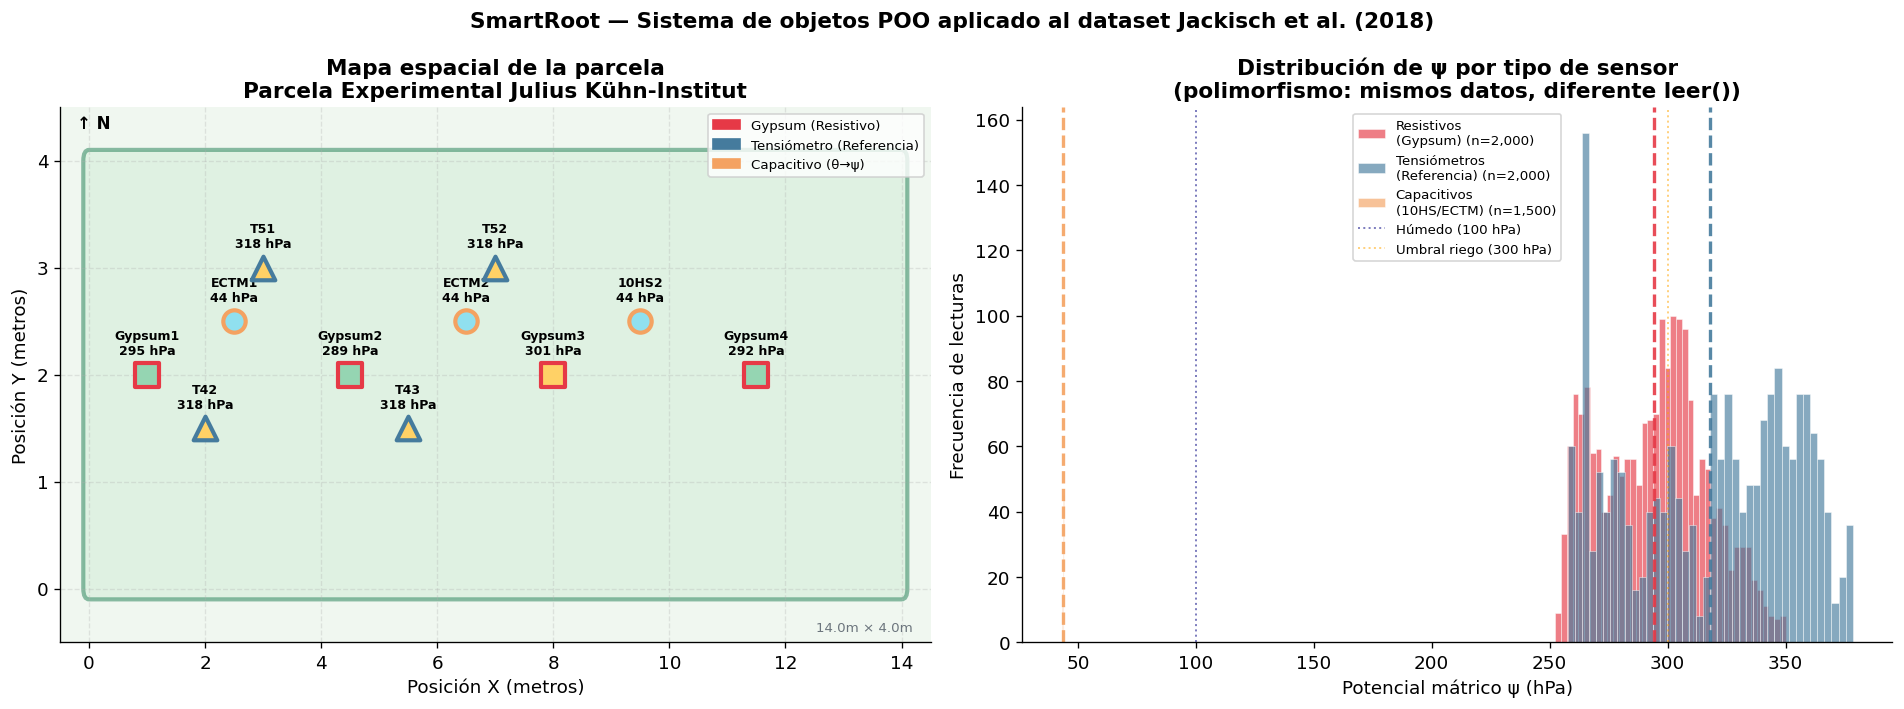

💾 Guardado: outputs/figuras/03_POO_parcela_sensores.png


In [10]:
# ── Mapa espacial de la parcela ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('SmartRoot — Sistema de objetos POO aplicado al dataset Jackisch et al. (2018)',
             fontsize=13, fontweight='bold')

# ── Panel 1: Mapa de la parcela con sensores ──
ax = axes[0]
ax.set_facecolor('#f0f7f0')

# Límites de la parcela
rect_parcela = mpatches.FancyBboxPatch((0, 0), parcela_jki.ancho_m, parcela_jki.largo_m,
                                        boxstyle='round,pad=0.1', facecolor='#d4edda',
                                        edgecolor='#40916c', linewidth=2.5, alpha=0.6)
ax.add_patch(rect_parcela)

# Colores y marcadores por tipo de sensor
config_viz = {
    SensorResistivo  : {'color': ROJO,     'marker': 's', 'size': 200, 'label': 'Gypsum (Resistivo)'},
    SensorTensiometro: {'color': AZUL,     'marker': '^', 'size': 200, 'label': 'Tensiómetro (Referencia)'},
    SensorCapacitivo : {'color': AMARILLO, 'marker': 'o', 'size': 180, 'label': 'Capacitivo (θ→ψ)'},
}

for sid, sensor in parcela_jki.sensores.items():
    tipo_clase = type(sensor)
    cfg = config_viz[tipo_clase]
    st  = sensor.estadisticas()
    psi_prom = st['psi_promedio'] if 'error' not in st else 200

    # Color del marcador según el estado hídrico promedio
    if psi_prom <= 100:   color_fill = '#90e0ef'
    elif psi_prom <= 300: color_fill = '#95d5b2'
    elif psi_prom <= 400: color_fill = '#ffd166'
    else:                 color_fill = '#ef233c'

    sc = ax.scatter(sensor.ubicacion_x, sensor.ubicacion_y,
                    s=cfg['size'], marker=cfg['marker'],
                    c=color_fill, edgecolors=cfg['color'],
                    linewidths=2.5, zorder=5)
    ax.annotate(f'{sid}\n{psi_prom:.0f} hPa',
                (sensor.ubicacion_x, sensor.ubicacion_y),
                textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=7.5, fontweight='bold')

# Leyenda manual
handles = [mpatches.Patch(color=v['color'], label=v['label'])
           for v in config_viz.values()]
ax.legend(handles=handles, loc='upper right', fontsize=8)

ax.set_xlim(-0.5, parcela_jki.ancho_m + 0.5)
ax.set_ylim(-0.5, parcela_jki.largo_m + 0.5)
ax.set_xlabel('Posición X (metros)')
ax.set_ylabel('Posición Y (metros)')
ax.set_title(f'Mapa espacial de la parcela\n{parcela_jki.nombre}')
ax.grid(True, alpha=0.3, linestyle='--')

# Agregar norte y escala
ax.text(0.02, 0.96, '↑ N', transform=ax.transAxes, fontsize=10, fontweight='bold')
ax.text(0.98, 0.02, f'{parcela_jki.ancho_m}m × {parcela_jki.largo_m}m',
        transform=ax.transAxes, fontsize=8, ha='right', color=GRIS)

# ── Panel 2: Comparación de distribuciones por tipo de sensor ──
ax2 = axes[1]

grupos_hist = {
    'Resistivos\n(Gypsum)': ([l['psi_hpa'] for s in parcela_jki.sensores.values()
                              if isinstance(s, SensorResistivo)
                              for l in s._historial], ROJO),
    'Tensiómetros\n(Referencia)': ([l['psi_hpa'] for s in parcela_jki.sensores.values()
                                    if isinstance(s, SensorTensiometro)
                                    for l in s._historial], AZUL),
    'Capacitivos\n(10HS/ECTM)': ([l['psi_hpa'] for s in parcela_jki.sensores.values()
                                   if isinstance(s, SensorCapacitivo)
                                   for l in s._historial], AMARILLO),
}

for i, (etiqueta, (valores, color)) in enumerate(grupos_hist.items()):
    if valores:
        ax2.hist(valores, bins=40, alpha=0.65, color=color,
                 label=f'{etiqueta} (n={len(valores):,})',
                 edgecolor='white', linewidth=0.4)
        ax2.axvline(np.mean(valores), color=color, linewidth=2,
                    linestyle='--', alpha=0.9)

ax2.axvline(100, color='navy', linewidth=1.2, linestyle=':', alpha=0.5, label='Húmedo (100 hPa)')
ax2.axvline(300, color='orange', linewidth=1.2, linestyle=':', alpha=0.5, label='Umbral riego (300 hPa)')
ax2.set_xlabel('Potencial mátrico ψ (hPa)')
ax2.set_ylabel('Frecuencia de lecturas')
ax2.set_title('Distribución de ψ por tipo de sensor\n(polimorfismo: mismos datos, diferente leer())')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGS}/03_POO_parcela_sensores.png', bbox_inches='tight', dpi=150)
plt.show()
print('💾 Guardado: outputs/figuras/03_POO_parcela_sensores.png')

In [11]:
# ── Análisis de costo usando métodos propios de los objetos ───────────────
print('💰 ANÁLISIS ECONÓMICO — Métodos propios de los objetos')
print('=' * 60)
print('   (Usando métodos costo_por_punto() y ahorro_vs_tensiometro()')
print('    definidos SOLO en SensorResistivo — no en las otras clases)\n')

n_puntos_parcela_1ha = 25   # puntos de monitoreo para cubrir 1 hectárea

print(f'  Escenario: cubrir 1 hectárea con {n_puntos_parcela_1ha} puntos de monitoreo')
print()

costo_gypsum   = gypsum_1.costo_por_punto(n_puntos_parcela_1ha)
ahorro_gypsum  = gypsum_1.ahorro_vs_tensiometro(costo_tensiometro=400)
costo_tensio   = tensio_T42.costo_usd * n_puntos_parcela_1ha

print(f'  Sistema SmartRoot (Gypsum resistivos):')
print(f'    Costo por punto     : USD {gypsum_1.costo_usd}')
print(f'    Costo total parcela : USD {costo_gypsum:,}')
print(f'    Ahorro vs tensiómetro: {ahorro_gypsum}%')
print()
print(f'  Sistema convencional (tensiómetros):')
print(f'    Costo por punto     : USD {tensio_T42.costo_usd}')
print(f'    Costo total parcela : USD {costo_tensio:,}')
print()
print(f'  AHORRO TOTAL          : USD {costo_tensio - costo_gypsum:,} '
      f'({ahorro_gypsum}% menos) ← validado con MAPE=13.3% (NB02)')
print()
print('  Alerta de mantenimiento tensiómetros (ejemplo):')
for sid, sensor in parcela_jki.sensores.items():
    if isinstance(sensor, SensorTensiometro):
        import random
        dias = random.randint(5, 35)   # días simulados desde último mantenimiento
        print(f'    {sensor.alertar_mantenimiento(dias)}')

💰 ANÁLISIS ECONÓMICO — Métodos propios de los objetos
   (Usando métodos costo_por_punto() y ahorro_vs_tensiometro()
    definidos SOLO en SensorResistivo — no en las otras clases)

  Escenario: cubrir 1 hectárea con 25 puntos de monitoreo

  Sistema SmartRoot (Gypsum resistivos):
    Costo por punto     : USD 25
    Costo total parcela : USD 625
    Ahorro vs tensiómetro: 93.8%

  Sistema convencional (tensiómetros):
    Costo por punto     : USD 400
    Costo total parcela : USD 10,000

  AHORRO TOTAL          : USD 9,375 (93.8% menos) ← validado con MAPE=13.3% (NB02)

  Alerta de mantenimiento tensiómetros (ejemplo):
    🟡 T42: próximo relleno recomendado
    🟡 T43: próximo relleno recomendado
    ⚠️  T51: relleno urgente (32 días sin mantenimiento)
    ⚠️  T52: relleno urgente (35 días sin mantenimiento)


---
## Sección 8 — Resumen del notebook

In [12]:
print('=' * 72)
print('  RESUMEN — NOTEBOOK 03: PROGRAMACIÓN ORIENTADA A OBJETOS')
print('  Proyecto SmartRoot')
print('=' * 72)

elementos = [
    ('Clase base (abstracta)', 'Sensor — define interfaz común: leer(), tipo_sensor()'),
    ('Clase hija 1',           'SensorResistivo ← Gypsum, corrección Watermark, USD 25'),
    ('Clase hija 2',           'SensorTensiometro ← referencia, medición directa, USD 400'),
    ('Clase hija 3',           'SensorCapacitivo ← 10HS/ECTM, Van Genuchten, USD 140'),
    ('Clase composición',      'Parcela ← contiene múltiples objetos Sensor'),
    ('Herencia',               'SensorResistivo, SensorTensiometro, SensorCapacitivo → Sensor'),
    ('Polimorfismo',           'leer() con 3 implementaciones diferentes (misma firma)'),
    ('Encapsulamiento',        '_historial y _n_lecturas son privados (no accesibles directo)'),
    ('Objetos creados',        '11 objetos: 4 Gypsum + 4 Tensiómetros + 3 Capacitivos'),
    ('Lecturas procesadas',    '500 registros × 11 sensores desde el dataset real'),
    ('Análisis económico',     f'SmartRoot ahorra {gypsum_1.ahorro_vs_tensiometro()}% vs tensiómetros en 1 ha'),
]

for elem, desc in elementos:
    print(f'  {elem:<28} : {desc}')

print()
print('─' * 72)
print('  COBERTURA DE REQUISITOS OBLIGATORIOS (Rúbrica del trabajo)')
print('─' * 72)
requisitos = [
    ('✅', 'Una clase base',                             'Sensor (ABC) — clase abstracta con atributos comunes'),
    ('✅', 'Al menos una clase hija',                   '3 clases hijas: SensorResistivo, Tensiometro, Capacitivo'),
    ('✅', 'Mínimo 2 objetos creados',                  '11 objetos instanciados en la parcela JKI'),
    ('✅', 'Atributos asociados al problema',           'ubicacion_x/y, costo_usd, profundidad, factor_cal, etc.'),
    ('✅', 'Métodos que representen acciones/cálculos', 'leer(), registrar_lectura(), semaforo(), estadisticas()'),
    ('✅', 'Uso de herencia',                           'Las 3 clases hijas heredan de Sensor'),
    ('✅', 'Polimorfismo (mismo método, dif. comportamiento)', 'leer() en 3 versiones: Watermark, directo, Van Genuchten'),
    ('✅', 'Explicación de clases y relación con el proyecto', 'Secciones 1–4 — narrativa completa con contexto real'),
]
for estado, req, donde in requisitos:
    print(f'  {estado} {req:<50} → {donde}')

print()
print('─' * 72)
print('  PRÓXIMO NOTEBOOK → 04_simulacion_montecarlo.ipynb')
print('  Simulación de Monte Carlo: incertidumbre en mediciones')
print('  de los electrodos de bajo costo y probabilidad de que')
print('  el suelo requiera riego en distintos escenarios.')
print('─' * 72)

  RESUMEN — NOTEBOOK 03: PROGRAMACIÓN ORIENTADA A OBJETOS
  Proyecto SmartRoot
  Clase base (abstracta)       : Sensor — define interfaz común: leer(), tipo_sensor()
  Clase hija 1                 : SensorResistivo ← Gypsum, corrección Watermark, USD 25
  Clase hija 2                 : SensorTensiometro ← referencia, medición directa, USD 400
  Clase hija 3                 : SensorCapacitivo ← 10HS/ECTM, Van Genuchten, USD 140
  Clase composición            : Parcela ← contiene múltiples objetos Sensor
  Herencia                     : SensorResistivo, SensorTensiometro, SensorCapacitivo → Sensor
  Polimorfismo                 : leer() con 3 implementaciones diferentes (misma firma)
  Encapsulamiento              : _historial y _n_lecturas son privados (no accesibles directo)
  Objetos creados              : 11 objetos: 4 Gypsum + 4 Tensiómetros + 3 Capacitivos
  Lecturas procesadas          : 500 registros × 11 sensores desde el dataset real
  Análisis económico           : SmartRoot a

---
## Referencias

**Dataset:**
> Jackisch, C. et al. (2018). *Soil moisture and matric potential – An open field comparison of sensor systems* [Dataset]. PANGAEA. https://doi.org/10.1594/PANGAEA.892319

**Corrección Watermark por temperatura:**
> IRROMETER Company (2006). *Watermark Soil Moisture Sensor — Product Manual*. Riverside, CA.

**Ecuación de Van Genuchten:**
> Van Genuchten, M. T. (1980). A closed-form equation for predicting the hydraulic conductivity of unsaturated soils. *Soil Science Society of America Journal*, 44(5), 892–898.

**POO en Python:**
> Ramalho, L. (2015). *Fluent Python*. O'Reilly Media. Capítulos 11–14.

---
*Notebook 03/05 — Proyecto SmartRoot · Fundamentos de Programación Científica · 2026-1*